In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from utility.my_colors import palette_dark, pink, blue, green, blueish_purple
from data.local.hamann_erq_desi_idxs import valid_sdss_names

settings = {
        'legend.frameon':False,
        'mathtext.fontset':'stix',
        'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [2]:
sdss_current_stats_path = "data/local/boss_current_best_measurements.csv"
desi_current_stats_path = "data/local/desi_current_best_measurements.csv"

sdss_df = pd.read_csv(sdss_current_stats_path)
# sdss_df = sdss_df.drop(columns=['absorption_relevant', 'rew', 'fwhm', 'kt80'])
# sdss_df = sdss_df.drop(columns=['absorption_relevant'])
# sdss_df = sdss_df.rename(columns={"z_dr12":"redshift"})
# sdss_df = sdss_df[sdss_df["sdss_name"].isin(valid_sdss_names)]
sdss_df = sdss_df.assign(survey="BOSS")
sdss_df = sdss_df.replace(np.nan,0)


desi_df = pd.read_csv(desi_current_stats_path)
desi_df = desi_df.assign(survey="DESI")
desi_df = desi_df.replace(np.nan,0)


stats_long = pd.concat([desi_df,sdss_df])
stats_long = stats_long.set_index(["sdss_name","survey"]).sort_values("sdss_name")

stats_short = desi_df.merge(sdss_df,on="sdss_name",suffixes=("_desi","_sdss"))
stats_short = stats_short.drop(columns=["survey_desi","survey_sdss","civ_rew_hamann_sdss","nv_rew_hamann_sdss","civ_fwhm_hamann_sdss","civ_kt80_hamann_sdss"])
stats_short = stats_short.rename(columns={"civ_rew_hamann_desi":"civ_rew_hamann","civ_kt80_hamann_desi":"civ_kt80_hamann","civ_fwhm_hamann_desi":"civ_fwhm_hamann"})

In [3]:
sdss_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sdss_name         97 non-null     object 
 1   civ_rew_hamann    97 non-null     float64
 2   nv_rew_hamann     97 non-null     float64
 3   civ_fwhm_hamann   97 non-null     float64
 4   civ_kt80_hamann   97 non-null     float64
 5   civ_fwhm_mine     97 non-null     float64
 6   civ_kt80_mine     97 non-null     float64
 7   civ_rew_mine      97 non-null     float64
 8   nv_rew_mine       97 non-null     float64
 9   lya_rew_mine      97 non-null     float64
 10  civ_fit_rew_mine  97 non-null     float64
 11  nv_fit_rew_mine   97 non-null     float64
 12  lya_fit_rew_mine  97 non-null     float64
 13  civ_rew_abs_diff  97 non-null     float64
 14  nv_rew_abs_diff   97 non-null     float64
 15  civ_rew_rel_diff  97 non-null     float64
 16  nv_rew_rel_diff   97 non-null     float64
 17 

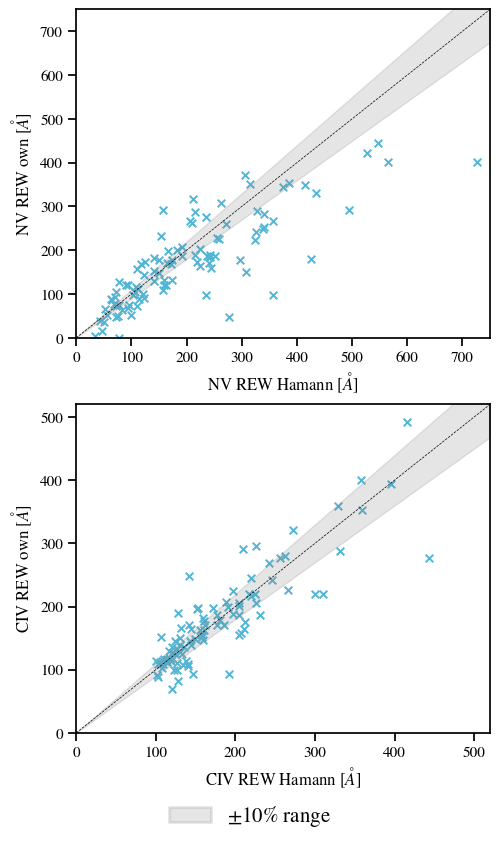

In [18]:
sns.set_context("notebook")
fig, ax = plt.subplots(2,1,figsize=(5,8))

# NV
lim0 = 750

sns.scatterplot(data=sdss_df,y="nv_rew_mine",x="nv_rew_hamann",marker="x",linewidth=1.4,s=30,color=blue,ax=ax[0])

ax[0].plot([0,lim0],[0,lim0],color="black",linestyle="--",linewidth=0.5)
ax[0].fill_between([0,lim0],[0,lim0-lim0*0.1],[0,lim0+lim0*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[0].set_xlim(0,lim0)
ax[0].set_ylim(0,lim0)
ax[0].set_xlabel(r"NV REW Hamann [$\AA$]")
ax[0].set_ylabel(r"NV REW own [$\AA$]")
ax[0].legend([],[])


# CIV
lim1 = 520

sns.scatterplot(data=sdss_df,y="civ_rew_mine",x="civ_rew_hamann",marker="x",linewidth=1.4,s=30,color=blue,ax=ax[1])

ax[1].plot([0,lim1],[0,lim1],color="black",linestyle="--",linewidth=0.5)
ax[1].fill_between([0,lim1],[0,lim1-lim1*0.1],[0,lim1+lim1*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[1].set_xlim(0,lim1)
ax[1].set_ylim(0,lim1)
ax[1].set_xlabel(r"CIV REW Hamann [$\AA$]")
ax[1].set_ylabel(r"CIV REW own [$\AA$]")
# ax[1].legend(frameon=False)



handles, labels = ax[0].get_legend_handles_labels()

leg = fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),  # push it below the subplots
    ncol=len(labels),              # one row, horizontal layout
    frameon=False,
    fontsize=15,
    markerscale=2
)

for legobj in leg.legend_handles:
    if isinstance(legobj, plt.Line2D):
        legobj.set_markeredgewidth(2)
    else:
        legobj.set_linewidth(2)

fig.tight_layout(pad=0.6)

plt.savefig("images/hamann_vs_mine_rew.svg")

plt.show()

In [5]:
# sns.set_context("notebook")
# fig, ax = plt.subplots(2,2,figsize=(10,8))

# # NV
# lim0 = 750

# sns.scatterplot(data=sdss_df,y="nv_rew_mine",x="nv_rew_hamann",marker="x",linewidth=1.4,s=30,color=blueish_purple,ax=ax[0,0])

# ax[0,0].plot([0,lim0],[0,lim0],color="black",linestyle="--",linewidth=0.5)
# ax[0,0].fill_between([0,lim0],[0,lim0-lim0*0.1],[0,lim0+lim0*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

# ax[0,0].set_xlim(0,lim0)
# ax[0,0].set_ylim(0,lim0)
# ax[0,0].set_xlabel(r"NV REW Hamann [$\AA$]")
# ax[0,0].set_ylabel(r"NV REW own [$\AA$]")
# ax[0,0].legend([],[])


# # CIV
# lim1 = 560

# sns.scatterplot(data=sdss_df,y="civ_rew_mine",x="civ_rew_hamann",marker="x",linewidth=1.4,s=30,color=blueish_purple,ax=ax[0,1])

# ax[0,1].plot([0,lim1],[0,lim1],color="black",linestyle="--",linewidth=0.5)
# ax[0,1].fill_between([0,lim1],[0,lim1-lim1*0.1],[0,lim1+lim1*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

# ax[0,1].set_xlim(0,lim1)
# ax[0,1].set_ylim(0,lim1)
# ax[0,1].set_xlabel(r"CIV REW Hamann [$\AA$]")
# ax[0,1].set_ylabel(r"CIV REW own [$\AA$]")
# # ax[0,1].legend(frameon=False)


# # CIV FWHM
# lim2 = 7000

# sns.scatterplot(data=sdss_df,y="civ_fwhm_mine",x="civ_fwhm_hamann",marker="x",linewidth=1.4,s=30,color=blue,ax=ax[1,0])

# ax[1,0].plot([0,lim2],[0,lim2],color="black",linestyle="--",linewidth=0.5)
# ax[1,0].fill_between([0,lim2],[0,lim2-lim2*0.1],[0,lim2+lim2*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

# ax[1,0].set_xlim(0,lim2)
# ax[1,0].set_ylim(0,lim2)
# ax[1,0].set_xlabel(r"CIV FWHM Hamann [$km~s^{-1}$]")
# ax[1,0].set_ylabel(r"CIV FWHM own [$km~s^{-1}$]")
# ax[1,0].legend([],[])


# # CIV kt80
# lim3 = 0.47

# sns.scatterplot(data=sdss_df,y="civ_kt80_mine",x="civ_kt80_hamann",marker="x",linewidth=1.4,s=30,color=blue,ax=ax[1,1])

# ax[1,1].plot([0,lim3],[0,lim3],color="black",linestyle="--",linewidth=0.5)
# ax[1,1].fill_between([0,lim3],[0,lim3-lim3*0.1],[0,lim3+lim3*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

# ax[1,1].set_xlim(0,lim3)
# ax[1,1].set_ylim(0,lim3)
# ax[1,1].set_xlabel(r"CIV kt80 Hamann")
# ax[1,1].set_ylabel(r"CIV kt80 own")
# # ax[0,1].legend(frameon=False)




# # handles, labels = ax[0].get_legend_handles_labels()

# # leg = fig.legend(
# #     handles, labels,
# #     loc='lower center',
# #     bbox_to_anchor=(0.5, -0.07),  # push it below the subplots
# #     ncol=len(labels),              # one row, horizontal layout
# #     frameon=False,
# #     fontsize=15,
# #     markerscale=2
# # )

# # for legobj in leg.legend_handles:
# #     if isinstance(legobj, plt.Line2D):
# #         legobj.set_markeredgewidth(2)
# #     else:
# #         legobj.set_linewidth(2)

# fig.tight_layout(pad=0.6)

# # plt.savefig("images/hamann_vs_mine_rew.svg")

# plt.show()

In [6]:
# # Hamann vs integration REW
# lim0 = 580
# sns.set_context("notebook")
# sns.scatterplot(data=stats_long,x="civ_rew_hamann",y="civ_rew_mine",hue="survey",marker="x",linewidth=1.4,s=30,palette=[pink,green])

# plt.plot([0,lim0],[0,lim0],color="black",linestyle="--",linewidth=0.5)
# plt.fill_between([0,lim0],[0,lim0-lim0*0.1],[0,lim0+lim0*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

# plt.xlim(0,lim0)
# plt.ylim(0,lim0)
# plt.xlabel(r"Hamann CIV REW [$\AA$]")
# plt.ylabel(r"CIV integration REW [$\AA$]")
# plt.legend(frameon=False,loc="lower right")
# plt.tight_layout()

# plt.show()


# # Hamann vs fit REW
# lim1 = 820
# sns.set_context("notebook")
# sns.scatterplot(data=stats_long,x="civ_rew_hamann",y="civ_fit_rew_mine",hue="survey",marker="x",linewidth=1.4,s=30,palette=[pink,green])

# plt.plot([0,lim1],[0,lim1],color="black",linestyle="--",linewidth=0.5)
# plt.fill_between([0,lim1],[0,lim1-lim1*0.1],[0,lim1+lim1*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

# plt.xlim(0,lim1)
# plt.ylim(0,lim1)
# plt.xlabel(r"Hamann CIV REW [$\AA$]")
# plt.ylabel(r"CIV fit REW [$\AA$]")
# plt.legend(frameon=False,loc="lower right")
# plt.tight_layout()

# plt.show()

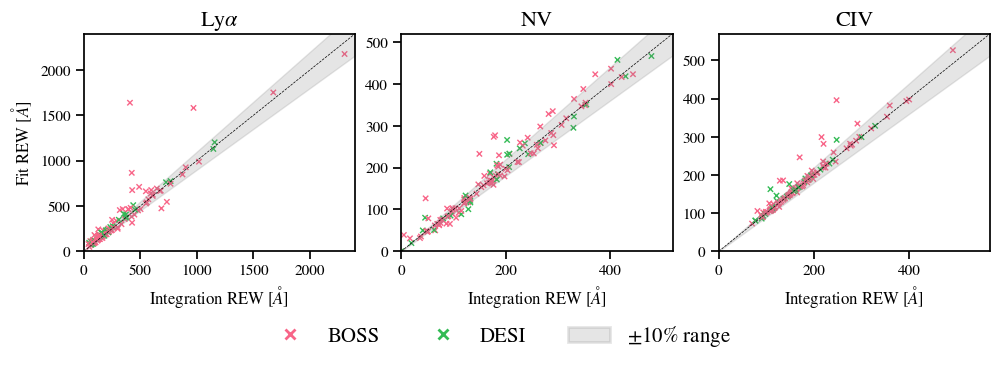

In [23]:
sns.set_context("notebook")

fig, ax = plt.subplots(1,3,figsize=(10,3.2))

# LYA
lim0 = 2400
sns.scatterplot(data=stats_long,x="lya_rew_mine",y="lya_fit_rew_mine",hue="survey",marker="x",linewidth=1,s=15,palette=[pink,green],ax=ax[0])

ax[0].plot([0,lim0],[0,lim0],color="black",linestyle="--",linewidth=0.5)
ax[0].fill_between([0,lim0],[0,lim0-lim0*0.1],[0,lim0+lim0*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[0].set_xlim(0,lim0)
ax[0].set_ylim(0,lim0)
ax[0].set_xlabel(r"Integration REW [$\AA$]")
ax[0].set_ylabel(r"Fit REW [$\AA$]")
ax[0].set_title(r"Ly$\alpha$",fontsize=16)
ax[0].legend([],[])


# NV
lim1 = 520
sns.scatterplot(data=stats_long,x="nv_rew_mine",y="nv_fit_rew_mine",hue="survey",marker="x",linewidth=1,s=15,palette=[pink,green],ax=ax[1])

ax[1].plot([0,lim1],[0,lim1],color="black",linestyle="--",linewidth=0.5)
ax[1].fill_between([0,lim1],[0,lim1-lim1*0.1],[0,lim1+lim1*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[1].set_xlim(0,lim1)
ax[1].set_ylim(0,lim1)
ax[1].set_xlabel(r"Integration REW [$\AA$]")
ax[1].set_ylabel(None)#r"NV fit REW [$\AA$]")
ax[1].set_title("NV",fontsize=16)
ax[1].legend([],[])


# CIV
lim2 = 570
sns.scatterplot(data=stats_long,x="civ_rew_mine",y="civ_fit_rew_mine",hue="survey",marker="x",linewidth=1,s=15,palette=[pink,green],ax=ax[2])
# ax[2].scatter(stats_long["civ_rew_mine"],stats_long["civ_fit_rew_mine"],linewidth=1,s=15,palette=[pink,green])

ax[2].plot([0,lim2],[0,lim2],color="black",linestyle="--",linewidth=0.5)
ax[2].fill_between([0,lim2],[0,lim2-lim2*0.1],[0,lim2+lim2*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[2].set_xlim(0,lim2)
ax[2].set_ylim(0,lim2)
ax[2].set_xlabel(r"Integration REW [$\AA$]")
ax[2].set_ylabel(None)#r"CIV fit REW [$\AA$]")
ax[2].set_title("CIV",fontsize=16)
ax[2].legend([],[])



handles, labels = ax[0].get_legend_handles_labels()

leg = fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),  # push it below the subplots
    ncol=len(labels),              # one row, horizontal layout
    frameon=False,
    fontsize=15,
    markerscale=2
)

for legobj in leg.legend_handles:
    if isinstance(legobj, plt.Line2D):
        legobj.set_markeredgewidth(2)
    else:
        legobj.set_linewidth(2)

fig.tight_layout(pad=0.6)

plt.savefig("images/integration_vs_fit.svg")

plt.show()

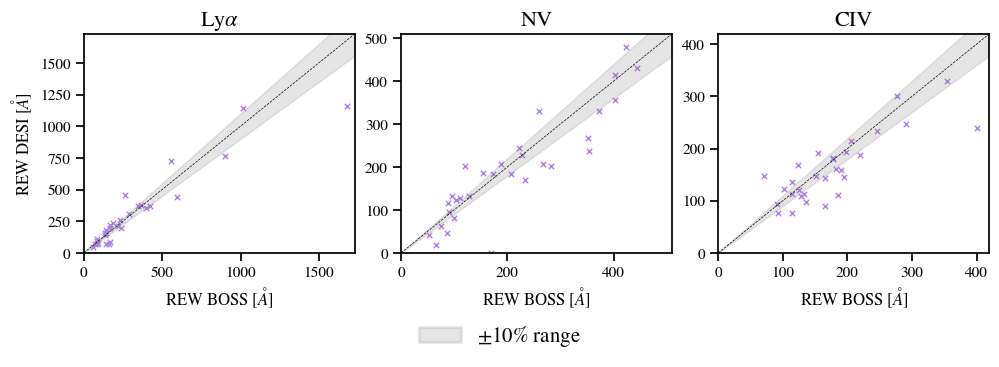

In [27]:
sns.set_context("notebook")



fig, ax = plt.subplots(1,3,figsize=(10,3.2))

# LYA
lim0 = 1730
sns.scatterplot(data=stats_short,x="lya_rew_mine_sdss",y="lya_rew_mine_desi",marker="x",linewidth=1,s=15,ax=ax[0],color=blueish_purple)

ax[0].plot([0,lim0],[0,lim0],color="black",linestyle="--",linewidth=0.5)
ax[0].fill_between([0,lim0],[0,lim0-lim0*0.1],[0,lim0+lim0*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[0].set_xlim(0,lim0)
ax[0].set_ylim(0,lim0)
ax[0].set_xlabel(r"REW BOSS [$\AA$]")
ax[0].set_ylabel(r"REW DESI [$\AA$]")
ax[0].set_title(r"Ly$\alpha$",fontsize=16)
ax[0].legend([],[])
# ax[0].legend(frameon=False,fontsize=10,bbox_to_anchor=(0.5, 1.03))


# NV
lim1 = 510
sns.scatterplot(data=stats_short,x="nv_rew_mine_sdss",y="nv_rew_mine_desi",marker="x",linewidth=1,s=15,ax=ax[1],color=blueish_purple)

ax[1].plot([0,lim1],[0,lim1],color="black",linestyle="--",linewidth=0.5)
ax[1].fill_between([0,lim1],[0,lim1-lim1*0.1],[0,lim1+lim1*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[1].set_xlim(0,lim1)
ax[1].set_ylim(0,lim1)
ax[1].set_xlabel(r"REW BOSS [$\AA$]")
ax[1].set_ylabel(None)#r"NV fit REW [$\AA$]")
ax[1].set_title("NV",fontsize=16)
ax[1].legend([],[])
# ax[1].legend(frameon=False,fontsize=10,bbox_to_anchor=(0.5, 1.03))


# CIV
lim2 = 420
sns.scatterplot(data=stats_short,x="civ_rew_mine_sdss",y="civ_rew_mine_desi",marker="x",linewidth=1,s=15,ax=ax[2],color=blueish_purple)

ax[2].plot([0,lim2],[0,lim2],color="black",linestyle="--",linewidth=0.5)
ax[2].fill_between([0,lim2],[0,lim2-lim2*0.1],[0,lim2+lim2*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

ax[2].set_xlim(0,lim2)
ax[2].set_ylim(0,lim2)
ax[2].set_xlabel(r"REW BOSS [$\AA$]")
ax[2].set_ylabel(None)#r"CIV fit REW [$\AA$]")
ax[2].set_title("CIV",fontsize=16)
ax[2].legend([],[])
# ax[2].legend(frameon=False,fontsize=10,bbox_to_anchor=(0.5, 1.03))


handles, labels = ax[0].get_legend_handles_labels()

leg = fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),  # push it below the subplots
    ncol=len(labels),              # one row, horizontal layout
    frameon=False,
    fontsize=15,
    markerscale=2
)

for legobj in leg.legend_handles:
    if isinstance(legobj, plt.Line2D):
        legobj.set_markeredgewidth(2)
    else:
        legobj.set_linewidth(2)

fig.tight_layout(pad=0.6)

plt.savefig("images/sdss_vs_desi_rew.svg")

plt.show()